In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
from scipy.integrate import quad
import math
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# Fridge Details

In [3]:
from library.fridges import TEMP_STAGES, FRIDGE_LIBRARY
# Assuming XLD1000sl
# We will use the operating temperatures and cable lengths corresponding to an XLD1000sl fridge
fridge = FRIDGE_LIBRARY["XLD1000SL"]
cooling_power_budget = fridge["cooling_power"]
operating_temp = fridge["temp"]
flange_separation = fridge["lengths"]

# Thermal Conductivity

In [4]:
# https://www.lakeshore.com/products/categories/specification/temperature-products/cryogenic-accessories/cryogenic-wire
## Manganin - # 83-Cu, 13-Mn, 4-Ni
x_temp = np.array([0.1, 0.4, 1, 4, 10, 20, 80, 150, 300])
y_k = np.array([0.006, 0.02, 0.06, 0.5, 2, 3.3, 13, 16, 22])

In [5]:
from library.cables import mn_thermal_conductivity

# Generate data points
x_vals = np.linspace(0,300,100)
y_vals = mn_thermal_conductivity(x_vals)

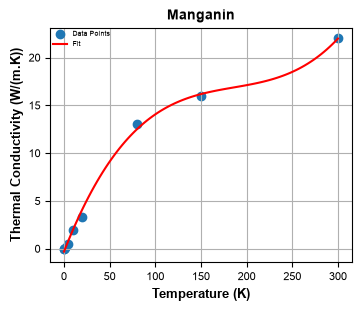

In [6]:
# Plot datapoints

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)

ax.scatter(x_temp, y_k, label='Data Points')
ax.plot(x_vals, y_vals, color='red', label='Fit')
ax.set_title("Manganin", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel('Thermal Conductivity (W/(m.K))', fontproperties=axis_label_font)
for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)

ax.legend(prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.grid(True)

plt.savefig(f"./mn_thermal_conductivity.png",dpi=600)
# 1966powellr.wThermalConductivitySelected (united1966thermal)
plt.show()

In [7]:
# PHL for one strand of manganin
def calc_PHL(cable_length, cable_diam, T_lo, T_hi): # cable lengths in cm
    # Integrate cu_thermal_conductivity(T) from T_hi to T_lo
    result, error = quad(mn_thermal_conductivity, T_lo, T_hi)
    # Get cross sectional area of wire 
    area = np.pi * (cable_diam/2)**2
    # For 3 wires per amplifier
    return result * (area/(cable_length*1E-2)) #cable length is in cm

# Assuming AWG30 wire
cable_diam = 0.2546E-3 # m (AWG30)

print("PHL for AWG30 Manganin")
for temp_stage in TEMP_STAGES[1:3]:
    # get cable length
    cable_length = flange_separation[temp_stage] # cm
    
    # get operating temperatures
    current_temp_stage_idx = TEMP_STAGES.index(temp_stage)
    if current_temp_stage_idx > 0:
        prev_temp_stage = TEMP_STAGES[current_temp_stage_idx - 1]
    T_lo = operating_temp[temp_stage]
    T_hi = operating_temp[prev_temp_stage]
    
    PHL = calc_PHL(cable_length, cable_diam, T_lo, T_hi)
    
    print(f"{temp_stage}:\t {PHL:.4e} W")

PHL for AWG30 Manganin
50K:	 6.9392e-04 W
4K:	 2.5470e-05 W


# Electrical Resistivity

A key feature of Manganin is that its resistance changes very little with temperature even at cryogenic temperatures.

Hence we can model the resistivity from 4K to 50K using a linear fit using the values provided in https://www.lakeshore.com/products/categories/specification/temperature-products/cryogenic-accessories/cryogenic-wire

In [8]:
from library.components import mn_electrical_resistivity, get_resistance

In [9]:
# https://www.lakeshore.com/products/categories/specification/temperature-products/cryogenic-accessories/cryogenic-wire
# For AWG30 wire
cable_diam = 0.2546E-3 # m (AWG30)
cable_area = np.pi * (cable_diam/2)**2

## Manganin - # 83-Cu, 13-Mn, 4-Ni
x_temp = np.array([4.2, 77, 305])
y_rho_data = np.array([8.64, 9.13, 9.69]) # Ohm/m for 30 AWG wire
y_rho = y_rho_data * cable_area

In [10]:
T_range = np.linspace(0, 310, 100)
rho_vals = mn_electrical_resistivity(T_range) # Ohm/m for 30 AWG wire

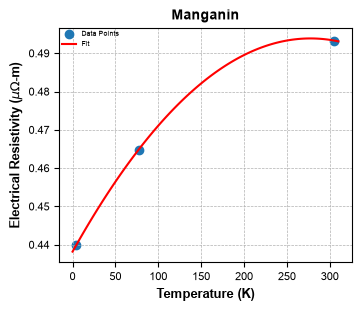

In [11]:
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)


ax.scatter(x_temp, y_rho*1E6, label='Data Points') # y-axis is in microohms-meter
ax.plot(T_range, rho_vals*1E6, color='red', label='Fit') # y-axis is in microohms-meter
# --- enable both major and minor grid lines ---
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

ax.set_title("Manganin", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel(r'Electrical Resistivity ($\mu\Omega$-m)', fontproperties=axis_label_font)

for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)

ax.legend(prop=legend_font,
          frameon=False,
          borderaxespad=0.)
plt.savefig(f"./mn_electrical_resistivity.png",dpi=600)
# https://www.twire.co.jp/english/Alloy2-en.html
# 2020xiangCharacterizationPressureCoefficient
plt.show()

In [12]:
# Assuming AWG30 wire
cable_diam = 0.2546E-3 # m (AWG30)
cable_area = np.pi * (cable_diam/2)**2

print("Resistance for AWG30 Manganin")
for temp_stage in TEMP_STAGES[1:3]:
    # get cable length
    cable_length = flange_separation[temp_stage]*1E-2 # cm to m
    
    # get operating temperatures
    current_temp_stage_idx = TEMP_STAGES.index(temp_stage)
    if current_temp_stage_idx > 0:
        prev_temp_stage = TEMP_STAGES[current_temp_stage_idx - 1]
    T_lo = operating_temp[temp_stage]
    T_hi = operating_temp[prev_temp_stage]

    # get_resistance() requires cable_length in meters
    resistance = get_resistance(mn_electrical_resistivity, cable_length, cable_area, T_lo, T_hi)
    
    print(f"{temp_stage}:\t {resistance:.4e} ohms")

Resistance for AWG30 Manganin
50K:	 2.8872e+00 ohms
4K:	 2.7670e+00 ohms
